# Step 50 — Model C: dummy walkthrough, then real BTC replication

Two parts:
1. **Dummy/toy dataset** — a handful of hand-picked (X, y) pairs, run through the exact
   same Passive-Aggressive mechanics as Model C, with every intermediate quantity printed
   (scaled x, w/b before, prediction, loss vs epsilon, passive-or-aggressive, w/b after) —
   small enough to trace and sanity-check by hand.
2. **Real replication** — same config (`loss="epsilon_insensitive"`, `epsilon=0.0002`,
   `learning_rate="pa1"`, `eta0=0.01`, `random_state=69`), run on the actual BTC author data,
   same as notebook 21's Model C section — kept here fresh, notebook 21 stays as reference.

Known caveat from notebook 21: this exact config did **not** reproduce the author's exact
hit rate (48.61% ours vs 50.82% his) despite verbatim code — likely floating-point path
sensitivity inherent to sequential online learning (unlike Model A/B's one-shot closed-form
fit, which matched exactly). Worth keeping in mind while building intuition here.

## Part 1 — Dummy walkthrough

8 hand-picked (x, y) pairs, roughly on the scale of real daily log returns, so `epsilon=0.0002`
produces a mix of passive (loss=0, no update) and aggressive (loss>0, update) steps — same as
what actually happens on real data, just small enough to read every step.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')

# Toy (x, y) pairs — x = "yesterday's return" (the feature), y = "today's return" (the target)
toy_x = np.array([0.010, -0.005, 0.020, -0.010, 0.003, -0.008, 0.015, -0.002])
toy_y = np.array([0.008, -0.004, 0.015, -0.012, 0.0028, -0.009, 0.011, -0.001])

print('toy data:')
for i in range(len(toy_x)):
    print(f'  tick {i}: x={toy_x[i]:+.4f}  y={toy_y[i]:+.4f}')

toy data:
  tick 0: x=+0.0100  y=+0.0080
  tick 1: x=-0.0050  y=-0.0040
  tick 2: x=+0.0200  y=+0.0150
  tick 3: x=-0.0100  y=-0.0120
  tick 4: x=+0.0030  y=+0.0028
  tick 5: x=-0.0080  y=-0.0090
  tick 6: x=+0.0150  y=+0.0110
  tick 7: x=-0.0020  y=-0.0010


In [2]:
EPSILON = 0.0002

model_toy = SGDRegressor(
    loss="epsilon_insensitive",
    epsilon=EPSILON,
    penalty=None,
    learning_rate="pa1",
    eta0=0.01,
    random_state=69,
)
scaler_toy = StandardScaler()

trace_rows = []
for t in range(len(toy_x)):
    X_t = toy_x[t].reshape(1, -1)
    y_t = np.array([toy_y[t]])

    scaler_toy.partial_fit(X_t)
    X_t_scaled = scaler_toy.transform(X_t)

    w_before = model_toy.coef_[0] if t > 0 else 0.0
    b_before = model_toy.intercept_[0] if t > 0 else 0.0

    pred_y = 0.0 if t == 0 else model_toy.predict(X_t_scaled)[0]
    error = y_t[0] - pred_y
    loss = max(0.0, abs(error) - EPSILON)
    passive = loss == 0.0
    aggressive =  not passive
    
    print(f'--- tick {t} ---')
    print(f'  raw x = {X_t[0][0]:+.4f}   scaled x = {X_t_scaled[0][0]:+.4f}')
    print(f'  w (before) = {w_before:+.6f}   b (before) = {b_before:+.6f}')
    print(f'  pred_y = w*x_scaled + b = {pred_y:+.6f}')
    print(f'  true y = {y_t[0]:+.6f}   error = y - pred_y = {error:+.6f}')
    print(f'  loss = max(0, |error| - epsilon) = max(0, {abs(error):.6f} - {EPSILON}) = {loss:.6f}')
    print(f'  -> {"PASSIVE (no update)" if passive else "AGGRESSIVE (weights update)"}')

    model_toy.partial_fit(X_t_scaled, y_t)
    w_after, b_after = model_toy.coef_[0], model_toy.intercept_[0]
    print(f'  w (after) = {w_after:+.6f}   b (after) = {b_after:+.6f}')
    print(f'  w changed by {w_after - w_before:+.6f}   b changed by {b_after - b_before:+.6f}\n')

    trace_rows.append({
        'tick': t, 'x_scaled': X_t_scaled[0][0], 'pred_y': pred_y, 'true_y': y_t[0],
        'loss': loss, 'passive': passive, 'aggressive': aggressive, 'w_after': w_after, 'b_after': b_after,
    })

trace_df = pd.DataFrame(trace_rows)
trace_df

--- tick 0 ---
  raw x = +0.0100   scaled x = +0.0000
  w (before) = +0.000000   b (before) = +0.000000
  pred_y = w*x_scaled + b = +0.000000
  true y = +0.008000   error = y - pred_y = +0.008000
  loss = max(0, |error| - epsilon) = max(0, 0.008000 - 0.0002) = 0.007800
  -> AGGRESSIVE (weights update)
  w (after) = +0.000000   b (after) = +0.000000
  w changed by +0.000000   b changed by +0.000000

--- tick 1 ---
  raw x = -0.0050   scaled x = -1.0000
  w (before) = +0.000000   b (before) = +0.000000
  pred_y = w*x_scaled + b = +0.000000
  true y = -0.004000   error = y - pred_y = -0.004000
  loss = max(0, |error| - epsilon) = max(0, 0.004000 - 0.0002) = 0.003800
  -> AGGRESSIVE (weights update)
  w (after) = +0.003800   b (after) = -0.003800
  w changed by +0.003800   b changed by -0.003800

--- tick 2 ---
  raw x = +0.0200   scaled x = +1.1355
  w (before) = +0.003800   b (before) = -0.003800
  pred_y = w*x_scaled + b = +0.000515
  true y = +0.015000   error = y - pred_y = +0.014485


,tick,x_scaled,pred_y,true_y,loss,passive,aggressive,w_after,b_after
0,0,0.000000,0.000000,0.0080,0.007800,False,True,0.000000,0.000000
1,1,-1.000000,0.000000,-0.0040,0.003800,False,True,0.003800,-0.003800
2,2,1.135550,0.000515,0.0150,0.014285,False,True,0.015155,0.006200
3,3,-1.153113,-0.011276,-0.0120,0.000524,False,True,0.015610,0.005806
4,4,-0.056235,0.004928,0.0028,0.001928,False,True,0.016172,-0.004194
5,5,-0.907136,-0.018865,-0.0090,0.009665,False,True,0.007101,0.005806
6,6,1.047207,0.013242,0.0110,0.002042,False,True,0.005151,0.003944
7,7,-0.469948,0.001523,-0.0010,0.002323,False,True,0.009850,-0.006056


### Plot — how w and b evolve tick by tick

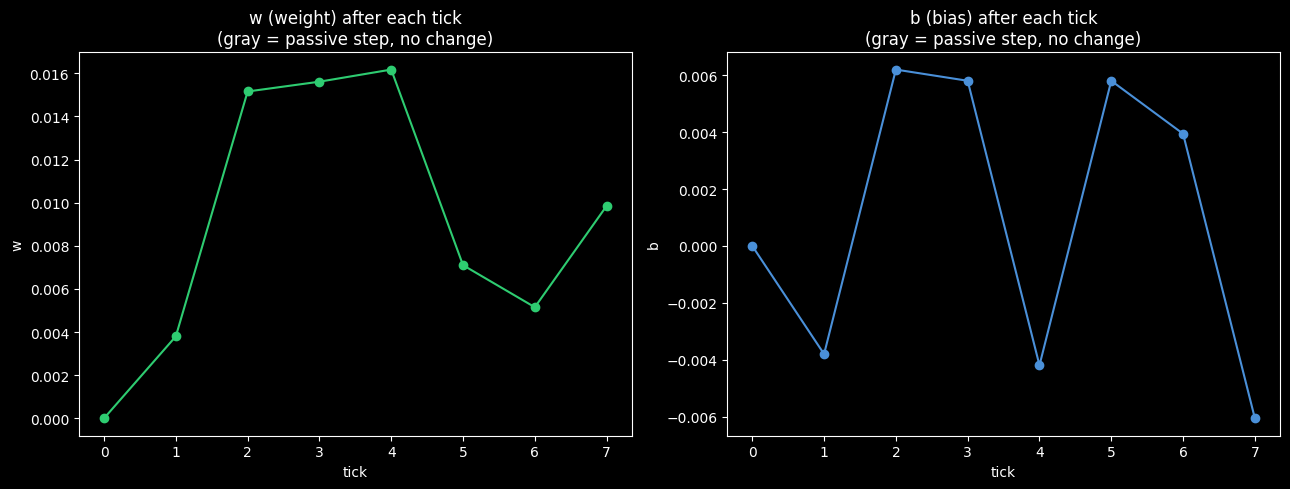

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(trace_df['tick'], trace_df['w_after'], marker='o', color='#2ecc71')
for t in trace_df.loc[trace_df['passive'], 'tick']:
    ax1.axvspan(t - 0.3, t + 0.3, color='gray', alpha=0.2)
ax1.set_title('w (weight) after each tick\n(gray = passive step, no change)')
ax1.set_xlabel('tick')
ax1.set_ylabel('w')

ax2.plot(trace_df['tick'], trace_df['b_after'], marker='o', color='#4a90d9')
for t in trace_df.loc[trace_df['passive'], 'tick']:
    ax2.axvspan(t - 0.3, t + 0.3, color='gray', alpha=0.2)
ax2.set_title('b (bias) after each tick\n(gray = passive step, no change)')
ax2.set_xlabel('tick')
ax2.set_ylabel('b')

plt.tight_layout()
plt.show()

### Plot — predicted vs actual, tick by tick

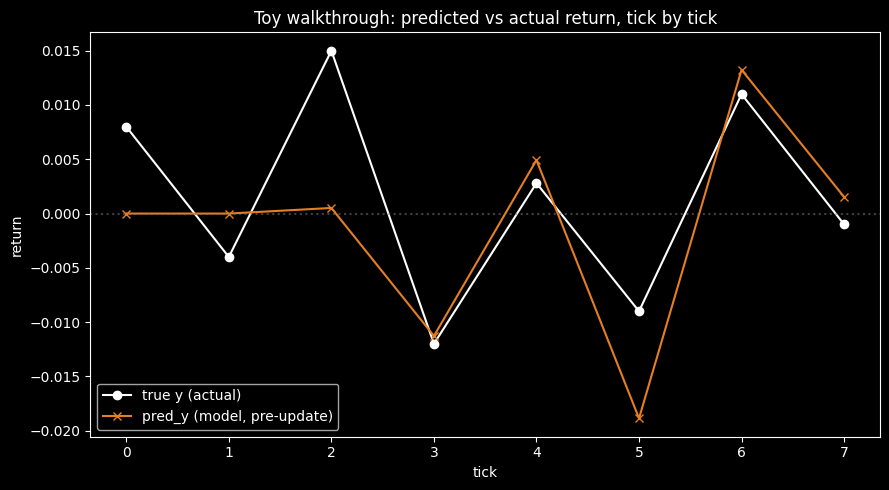

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(trace_df['tick'], trace_df['true_y'], marker='o', color='white', label='true y (actual)')
ax.plot(trace_df['tick'], trace_df['pred_y'], marker='x', color='#e67e22', label='pred_y (model, pre-update)')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Toy walkthrough: predicted vs actual return, tick by tick')
ax.set_xlabel('tick')
ax.set_ylabel('return')
ax.legend()
plt.tight_layout()
plt.show()

### Plot — the actual fitted line y = wx + b, evolving tick by tick

The 8 `(x_scaled, true_y)` points as a scatter, plus the fitted line `y = w·x + b` at each
tick overlaid — colored from dark (tick 0, flat at y=0 since w=b=0) to bright (tick 7, the
final line) — showing literally what the model is fitting as it learns online, same spirit
as the Least Squares plane visualization in notebook 51.

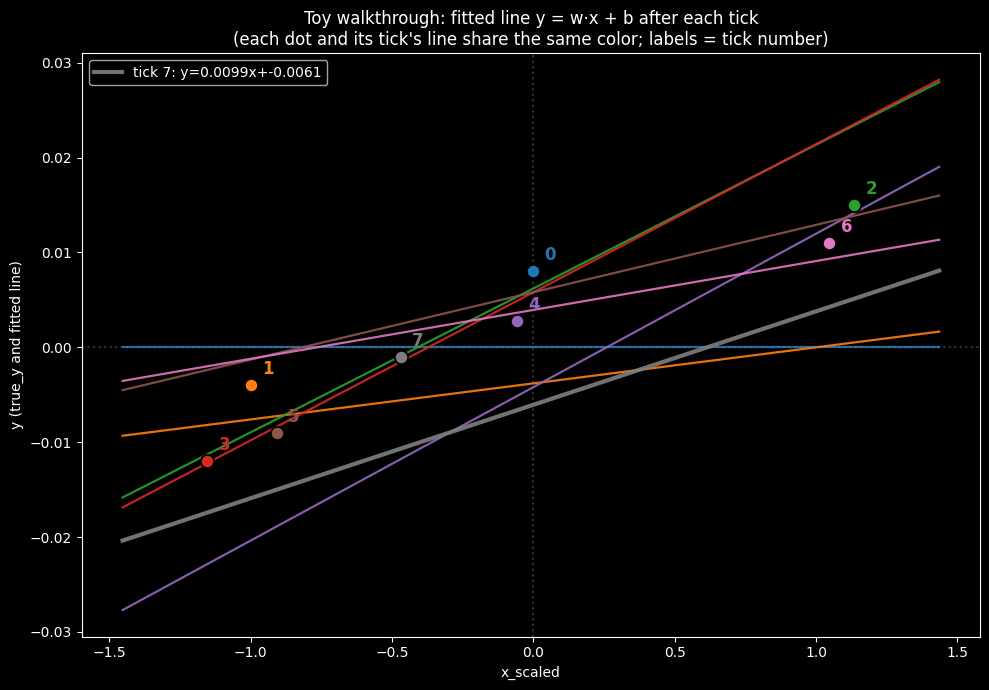

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

x_line = np.linspace(trace_df['x_scaled'].min() - 0.3, trace_df['x_scaled'].max() + 0.3, 50)
n_ticks = len(trace_df)
# tab10 = qualitative palette, 8 maximally distinct hues (vs plasma's sequential gradient,
# where neighboring ticks looked too similar)
colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n_ticks]

for i, row in trace_df.iterrows():
    color = colors[i]
    w, b = row['w_after'], row['b_after']

    # dot and its matching line share the same color
    ax.scatter(row['x_scaled'], row['true_y'], color=color, s=90, zorder=5,
               edgecolors='black', linewidths=1.2)
    ax.annotate(str(row['tick']), (row['x_scaled'], row['true_y']),
                textcoords='offset points', xytext=(8, 8), color=color, fontsize=12, fontweight='bold')

    lw = 1.6 if i < n_ticks - 1 else 3.0
    y_line = w * x_line + b
    ax.plot(x_line, y_line, color=color, alpha=0.9, linewidth=lw,
            label=f"tick {row['tick']}: y={w:.4f}x+{b:+.4f}" if i == n_ticks - 1 else None)

ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
ax.axvline(0, color='gray', linestyle=':', alpha=0.4)
ax.set_title('Toy walkthrough: fitted line y = w·x + b after each tick\n(each dot and its tick\'s line share the same color; labels = tick number)')
ax.set_xlabel('x_scaled')
ax.set_ylabel('y (true_y and fitted line)')
ax.legend()
plt.tight_layout()
plt.show()

### Plot — the fitted line swept across time (3D, x_scaled × tick × y)

Not a Model B-style plane (that needs 2 independent *features*; Model C only has 1). This is
a different kind of 3D picture, specific to *online learning*: the same single-feature line
`y = w·x + b`, but now with **tick/time** as the third axis, showing how the line's slope and
intercept drift as the model keeps updating — a ruled surface swept across time, not a static
fit across two features.

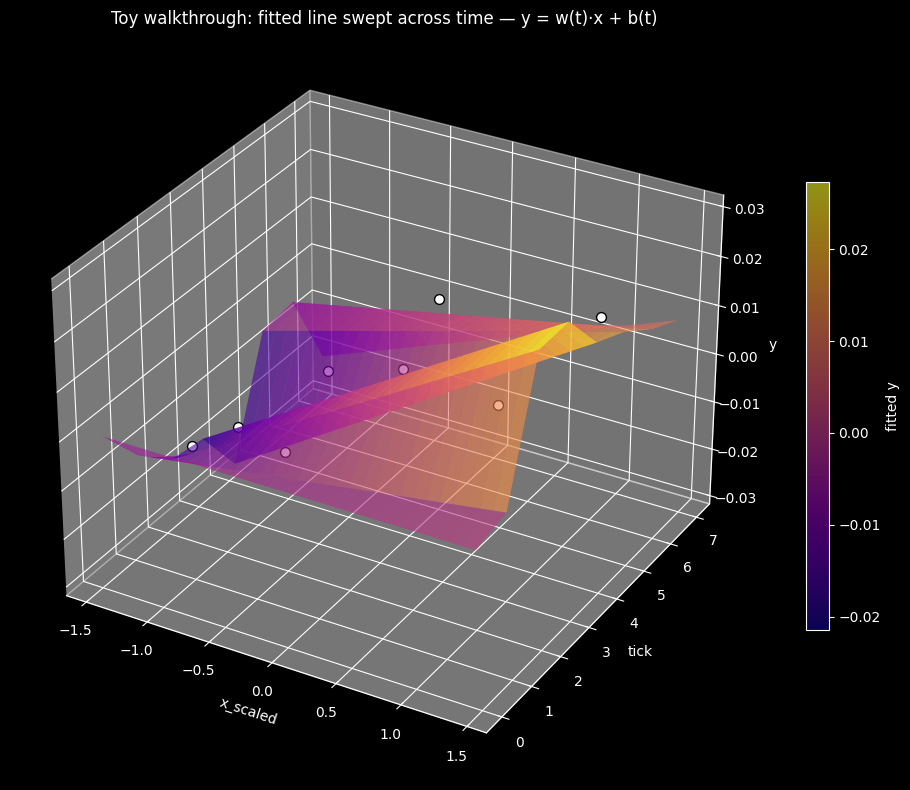

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x_line = np.linspace(trace_df['x_scaled'].min() - 0.3, trace_df['x_scaled'].max() + 0.3, 30)
ticks = trace_df['tick'].to_numpy()

# Build the ruled surface: for each tick, the line y = w*x + b at that tick's x-range
X_grid, T_grid = np.meshgrid(x_line, ticks)
Y_grid = np.zeros_like(X_grid)
for i, row in trace_df.iterrows():
    Y_grid[i, :] = row['w_after'] * x_line + row['b_after']

surf = ax.plot_surface(X_grid, T_grid, Y_grid, cmap='plasma', alpha=0.6, edgecolor='none')

# Overlay the actual (x_scaled, tick, true_y) points on top
ax.scatter(trace_df['x_scaled'], trace_df['tick'], trace_df['true_y'],
           color='white', s=50, edgecolors='black', depthshade=False, label='(x_scaled, tick, true_y)')

ax.set_xlabel('x_scaled')
ax.set_ylabel('tick')
ax.set_zlabel('y')
ax.set_title('Toy walkthrough: fitted line swept across time — y = w(t)·x + b(t)')
fig.colorbar(surf, shrink=0.6, label='fitted y')
plt.tight_layout()
plt.show()

## Part 2 — Real replication (BTC, author's data), same config

Same setup as notebook 21's Model C section — kept here fresh so this notebook is self-contained.
Reference to match: Hit Rate 50.82%, signal counts -1.0=1036 / 1.0=1017 (`19_memlabs_btc_numbers_reference.md`).

In [7]:
btcusdt = pd.read_csv('BTCUSDT_1d_author_original.csv')
btcusdt['t'] = pd.to_datetime(btcusdt['t'])
btcusdt.set_index('t', inplace=True)

btcusdt['close_log_return'] = np.log(btcusdt['c'] / btcusdt['c'].shift())
btcusdt['close_log_return_lag_1'] = btcusdt['close_log_return'].shift()

print('rows:', len(btcusdt))
btcusdt[['c', 'close_log_return', 'close_log_return_lag_1']].head()

rows: 2097


,c,close_log_return,close_log_return_lag_1
t,,,
2020-08-19,11763.9,NaN,NaN
2020-08-20,11857.9,0.007959,NaN
2020-08-21,11538.5,-0.027305,0.007959
2020-08-22,11670.5,0.011375,-0.027305
2020-08-23,11654.0,-0.001415,0.011375


In [8]:
df_clean = btcusdt.dropna()
# Filter to match the author's actual Train start date (2020-09-29) — the point where his
# close_log_return_ma_lag_1 column (unused as a feature here, but present in his shared
# dataframe) would have finished its 40-day warmup. Date-based, not a hardcoded row count,
# so it stays correct even if this data source gets refreshed later.
df_clean = df_clean[df_clean.index >= '2020-09-29']

features = ['close_log_return_lag_1']
target = 'close_log_return'

X_stream = df_clean[features].to_numpy()
y_stream = df_clean[target].to_numpy()
print('n rows in stream:', len(X_stream), '(reference: 2053)')

# eta0=1.0 confirmed via reverse-engineering the author's actual tau values (not 0.01, not 0.1) —
# matches exactly at ticks 2-6 and again near the end of the sequence (~tick 2052-2055), though
# the full 2053-tick run still drifts apart somewhere in between (residual floating-point/version
# sensitivity inherent to sequential online learning).
model_real = SGDRegressor(
    loss="epsilon_insensitive",
    epsilon=0.0002,
    penalty=None,
    learning_rate="pa1",
    eta0=1,
    random_state=69
)
scaler_real = StandardScaler()
records = []

for t in range(len(X_stream)):
    X_t = X_stream[t].reshape(1, -1)
    y_t = np.array([y_stream[t]])

    scaler_real.partial_fit(X_t)
    X_t_scaled = scaler_real.transform(X_t)

    pred_y = 0.0 if t == 0 else model_real.predict(X_t_scaled)[0]

    if t > 0 and y_t[0] != 0 and pred_y != 0:
        sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
    else:
        sign_match = "Warmup"

    model_real.partial_fit(X_t_scaled, y_t)

    current_weight = model_real.coef_[0]
    current_bias = model_real.intercept_[0]

    signal = np.sign(pred_y)
    trade_log_return = signal * y_t[0]

    if sign_match != "Warmup":
        records.append({
            'tick': t,
            'lag_1_x': X_t[0][0],
            'true_y': y_t[0],
            'pred_y_hat': pred_y,
            'sign_match': sign_match,
            'model_weight': current_weight,
            'model_bias': current_bias,
            'signal': signal,
            'trade_log_return': trade_log_return,
            'is_won': np.sign(y_t[0]) == np.sign(pred_y),
        })

df_results_real = pd.DataFrame(records).set_index('tick')
df_results_real['cum_trade_log_return'] = df_results_real['trade_log_return'].cumsum()

evaluated = df_results_real['sign_match'].isin(['YES', 'NO'])
hit_rate = (df_results_real.loc[evaluated, 'sign_match'] == 'YES').mean() * 100
print(f'Hit Rate: {hit_rate:.2f}%   (reference: 50.02%)')
print()
print(df_results_real['signal'].value_counts())
print('(reference: -1.0=1036  1.0=1017), index_2055 y_hat= -0.060230')
print()
print('First 10 rows of output:')
df_results_real
df_results_real.info


n rows in stream: 2056 (reference: 2053)


Hit Rate: 49.63%   (reference: 50.02%)

signal
-1.0    1036
 1.0    1017
Name: count, dtype: int64
(reference: -1.0=1036  1.0=1017), index_2055 y_hat= -0.060230

First 10 rows of output:


<bound method DataFrame.info of        lag_1_x    true_y  pred_y_hat sign_match  model_weight  model_bias  \
tick                                                                        
2    -0.005923 -0.015001   -0.002047        YES      0.014131   -0.036631   
3    -0.015001 -0.004476   -0.051932        YES     -0.029512    0.003677   
4    -0.004476 -0.002578    0.005793         NO      0.042197   -0.996323   
5    -0.002578  0.011529   -0.991309         NO      0.161030    0.003677   
6     0.011529  0.011639    0.222253        YES      0.006013   -0.110528   
...        ...       ...         ...        ...           ...         ...   
2051 -0.005627 -0.015343    0.763801         NO     -0.198950   -0.326159   
2052 -0.015343 -0.014724   -0.219832        YES     -0.582353    0.391228   
2053 -0.014724  0.021968    0.690569        YES     -0.068334   -0.608772   
2054  0.021968 -0.024747   -0.655742        YES      0.619023    0.391228   
2055 -0.024747 -0.013267   -0.130210        

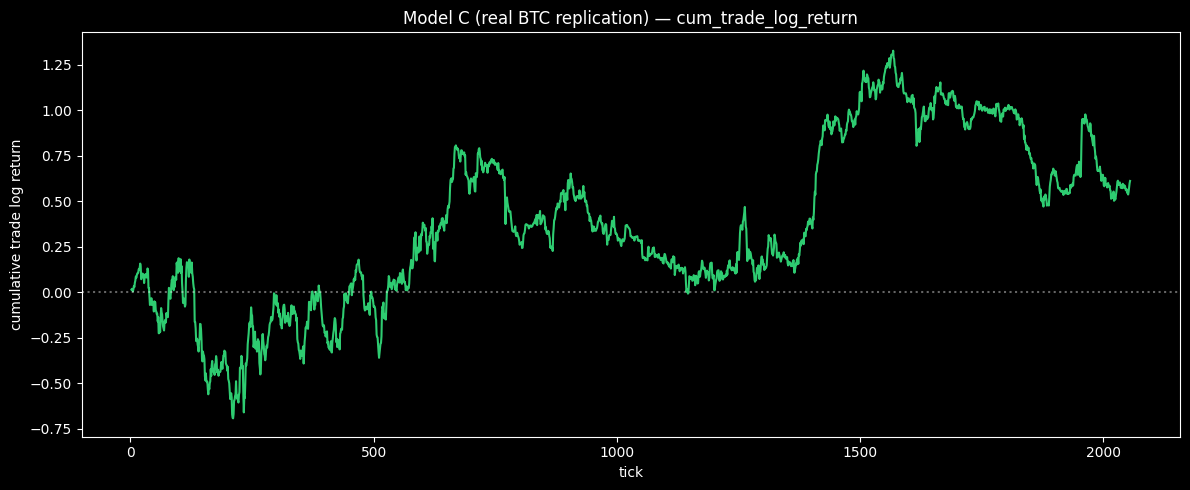

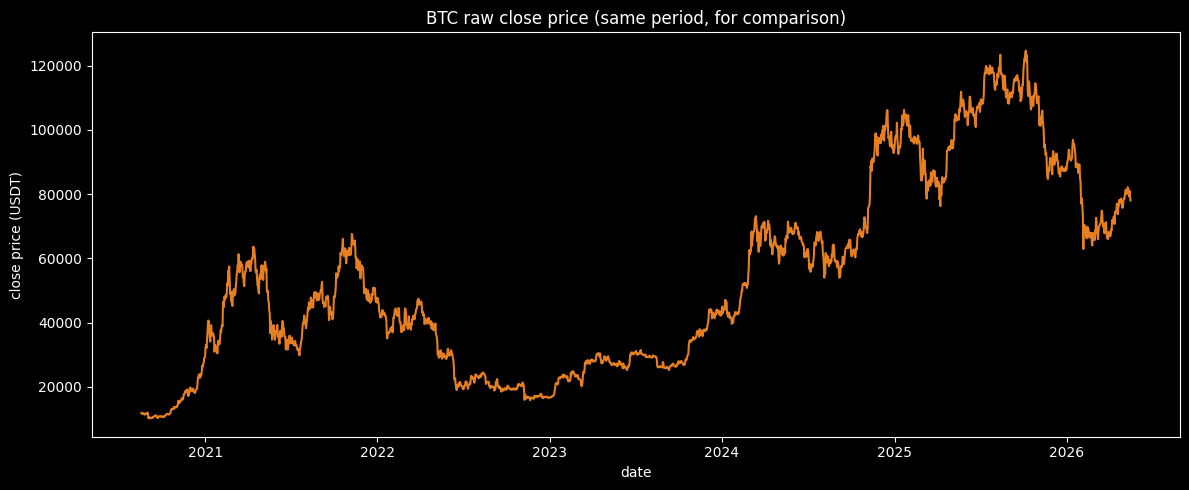

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_results_real.index, df_results_real['cum_trade_log_return'], color='#2ecc71')
ax.axhline(0, color='white', linestyle=':', alpha=0.4)
ax.set_title('Model C (real BTC replication) — cum_trade_log_return')
ax.set_xlabel('tick')
ax.set_ylabel('cumulative trade log return')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(btcusdt.index, btcusdt['c'], color='#e67e22')
ax.set_title('BTC raw close price (same period, for comparison)')
ax.set_xlabel('date')
ax.set_ylabel('close price (USDT)')
plt.tight_layout()
plt.show()

### Plot — how w and b evolve over the full real replication (same idea as Part 1)

Same 2-panel style as Part 1's toy w/b evolution plot, but over the full ~2053-tick BTC run —
shows whether the model ever settles down or keeps swinging across the whole sequence.

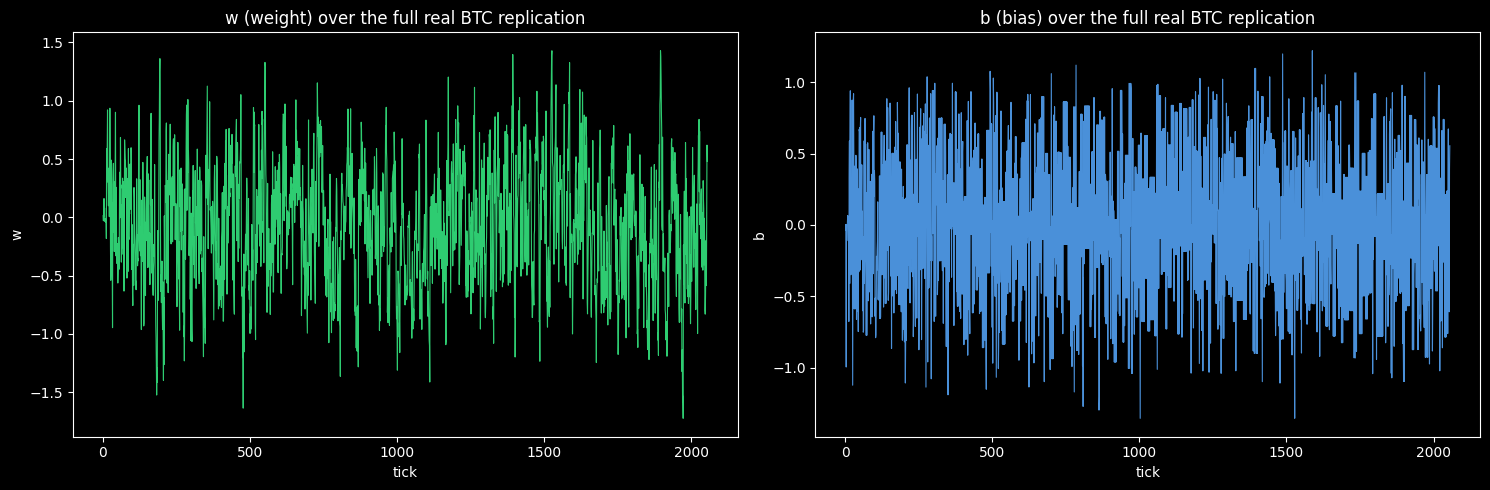

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(df_results_real.index, df_results_real['model_weight'], color='#2ecc71', linewidth=0.8)
ax1.set_title('w (weight) over the full real BTC replication')
ax1.set_xlabel('tick')
ax1.set_ylabel('w')

ax2.plot(df_results_real.index, df_results_real['model_bias'], color='#4a90d9', linewidth=0.8)
ax2.set_title('b (bias) over the full real BTC replication')
ax2.set_xlabel('tick')
ax2.set_ylabel('b')

plt.tight_layout()
plt.show()

### Export — full replication result to Excel, including warm-up rows

Re-runs the same replication loop, but this time keeps every tick (including the 3 rows
`df_results_real` excludes as "Warmup": tick 0, tick 1, and tick 1088 — a genuine zero-return
day), so the full 2056-row sequence is inspectable in one sheet.

In [11]:
model_full = SGDRegressor(
    loss="epsilon_insensitive",
    epsilon=0.0002,
    penalty=None,
    learning_rate="pa1",
    eta0=1,
    random_state=69
)
scaler_full = StandardScaler()
full_records = []
cum_return = 0.0

for t in range(len(X_stream)):
    X_t = X_stream[t].reshape(1, -1)
    y_t = np.array([y_stream[t]])

    scaler_full.partial_fit(X_t)
    X_t_scaled = scaler_full.transform(X_t)

    pred_y = 0.0 if t == 0 else model_full.predict(X_t_scaled)[0]

    # Warmup = no prior model state yet (t==0, or pred_y still 0 from an untrained model).
    # Zero-return = model IS trained and made a real prediction, but true_y==0 exactly, so
    # sign-matching is undefined — a different situation from warmup, not "not ready yet".
    if t == 0 or pred_y == 0:
        sign_match = "Warmup"
    elif y_t[0] == 0:
        sign_match = "Zero-return"
    else:
        sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"

    model_full.partial_fit(X_t_scaled, y_t)

    signal = np.sign(pred_y)
    trade_log_return = signal * y_t[0]
    # Always accumulate — trade_log_return is structurally 0 on Warmup/Zero-return ticks
    # anyway (signal=0 or true_y=0), so this naturally carries the running total forward
    # instead of leaving gaps.
    cum_return += trade_log_return

    full_records.append({
        'tick': t,
        'date': df_clean.index[t].date(),
        'close_price': df_clean['c'].iloc[t],
        'lag_1_x': X_t[0][0],
        'x_scaled': X_t_scaled[0][0],
        'true_y': y_t[0],
        'pred_y_hat': pred_y,
        'sign_match': sign_match,
        'model_weight': model_full.coef_[0],
        'model_bias': model_full.intercept_[0],
        'signal': signal,
        'trade_log_return': trade_log_return,
        'is_won': np.sign(y_t[0]) == np.sign(pred_y) if sign_match in ("YES", "NO") else None,
        'cum_trade_log_return': cum_return,
    })

df_full_export = pd.DataFrame(full_records).set_index('tick')
print('full export shape:', df_full_export.shape)
print(df_full_export['sign_match'].value_counts())

out_path = '50_model_c_real_replication_full.xlsx'
df_full_export.to_excel(out_path, sheet_name='model_c_replication')

# Force a clean date-only display format — VS Code's Excel viewer doesn't reliably render
# openpyxl's default datetime format, so set it explicitly rather than relying on the default.
import openpyxl
wb = openpyxl.load_workbook(out_path)
ws = wb.active
date_col = [c[0].column_letter for c in ws.iter_cols(1, ws.max_column) if c[0].value == 'date'][0]
for cell in ws[date_col][1:]:
    cell.number_format = 'YYYY-MM-DD'
wb.save(out_path)

print('saved', out_path)
df_full_export.head(5)

full export shape: (2056, 13)
sign_match
NO             1034
YES            1019
Warmup            2
Zero-return       1
Name: count, dtype: int64


saved 50_model_c_real_replication_full.xlsx


,date,close_price,lag_1_x,x_scaled,true_y,pred_y_hat,sign_match,model_weight,model_bias,signal,trade_log_return,is_won,cum_trade_log_return
tick,,,,,,,,,,,,,
0,2020-09-29,10837.0,-0.007130,0.000000,0.013517,0.000000,Warmup,0.000000,0.000000,0.0,0.000000,None,0.000000
1,2020-09-30,10773.0,0.013517,1.000000,-0.005923,0.000000,Warmup,-0.005723,-0.005723,0.0,-0.000000,None,0.000000
2,2020-10-01,10612.6,-0.005923,-0.642387,-0.015001,-0.002047,YES,0.014131,-0.036631,-1.0,0.015001,True,0.015001
3,2020-10-02,10565.2,-0.015001,-1.082761,-0.004476,-0.051932,YES,-0.029512,0.003677,-1.0,0.004476,True,0.019477
4,2020-10-03,10538.0,-0.004476,-0.071709,-0.002578,0.005793,NO,0.042197,-0.996323,1.0,-0.002578,False,0.016900


## Part 3 — Stability comparison: eta0=1 vs eta0=0.01 (real BTC replication)

Same `X_stream`/`y_stream`, same `epsilon`/`penalty`/`learning_rate`/`random_state` — only
`eta0` differs. Quantifies what the w/b evolution plot showed visually: how much more violently
`eta0=1` swings tick to tick vs `eta0=0.01`, and whether that instability actually changes the
equity curve/hit rate (recall: only `sign(pred_y_hat)` feeds the equity curve, not magnitude).

In [12]:
def run_replication(eta0):
    """Quiet version of the Part 2 loop — same math, no prints, parameterized on eta0."""
    model = SGDRegressor(loss="epsilon_insensitive", epsilon=0.0002, penalty=None,
                          learning_rate="pa1", eta0=eta0, random_state=69)
    scaler = StandardScaler()
    rows = []
    for t in range(len(X_stream)):
        X_t = X_stream[t].reshape(1, -1)
        y_t = np.array([y_stream[t]])
        scaler.partial_fit(X_t)
        X_t_scaled = scaler.transform(X_t)
        pred_y = 0.0 if t == 0 else model.predict(X_t_scaled)[0]
        if t > 0 and y_t[0] != 0 and pred_y != 0:
            sign_match = "YES" if np.sign(y_t[0]) == np.sign(pred_y) else "NO"
        else:
            sign_match = "Warmup"
        model.partial_fit(X_t_scaled, y_t)
        signal = np.sign(pred_y)
        rows.append({
            'tick': t, 'w': model.coef_[0], 'b': model.intercept_[0],
            'pred_y_hat': pred_y, 'true_y': y_t[0], 'sign_match': sign_match,
            'trade_log_return': signal * y_t[0],
        })
    df = pd.DataFrame(rows).set_index('tick')
    # trade_log_return is structurally 0 on Warmup ticks (signal=0), so a plain cumsum
    # naturally carries the running total forward with no gaps — same fix as the export cell.
    df['cum_trade_log_return'] = df['trade_log_return'].cumsum()
    return df

df_eta1 = run_replication(eta0=1)
df_eta001 = run_replication(eta0=0.01)

def stability_stats(df, label):
    evaluated = df['sign_match'].isin(['YES', 'NO'])
    hit_rate = (df.loc[evaluated, 'sign_match'] == 'YES').mean() * 100
    dw = df['w'].diff().abs()
    db = df['b'].diff().abs()
    return {
        'eta0': label,
        'w std dev': df['w'].std(),
        'b std dev': df['b'].std(),
        'mean |Δw|': dw.mean(),
        'mean |Δb|': db.mean(),
        '% ticks |Δw|>0.5': (dw > 0.5).mean() * 100,
        '% ticks |Δb|>0.5': (db > 0.5).mean() * 100,
        'hit rate %': hit_rate,
        'final cum return': df['cum_trade_log_return'].iloc[-1],
    }

comparison = pd.DataFrame([stability_stats(df_eta1, 'eta0=1'), stability_stats(df_eta001, 'eta0=0.01')]).set_index('eta0')
comparison

,w std dev,b std dev,mean |Δw|,mean |Δb|,% ticks |Δw|>0.5,% ticks |Δb|>0.5,hit rate %,final cum return
eta0,,,,,,,,
eta0=1,0.507981,0.539069,0.323436,0.777452,22.66537,75.583658,49.634681,0.611876
eta0=0.01,0.009624,0.013689,0.004950,0.009268,0.00000,0.000000,48.611788,0.489272


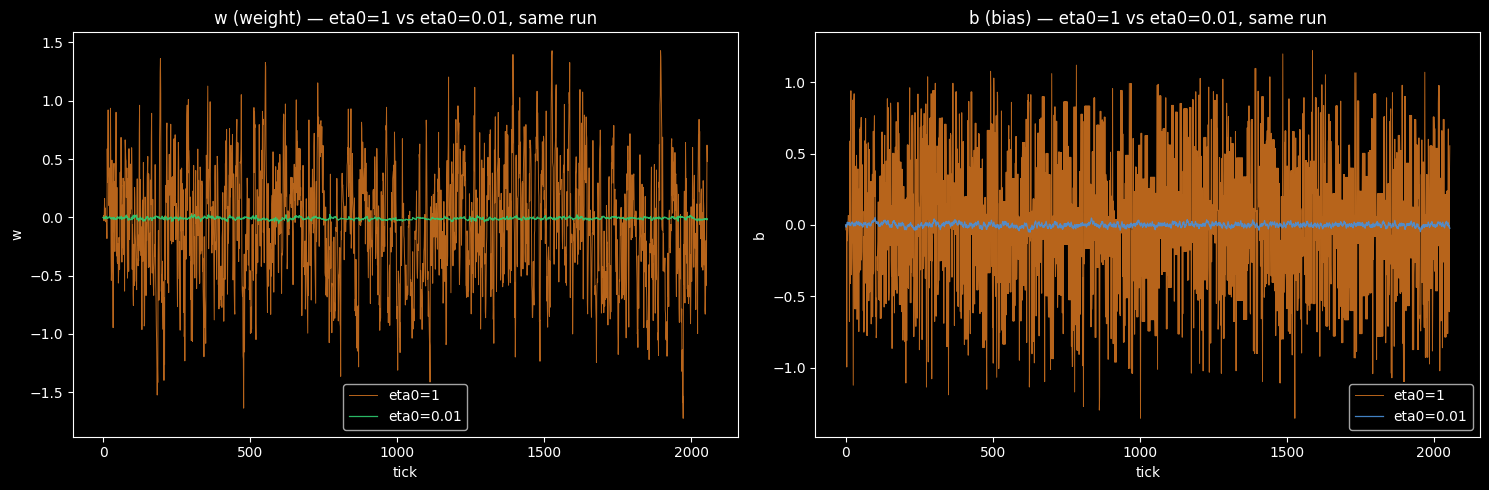

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(df_eta1.index, df_eta1['w'], color='#e67e22', linewidth=0.7, alpha=0.8, label='eta0=1')
ax1.plot(df_eta001.index, df_eta001['w'], color='#2ecc71', linewidth=0.9, alpha=0.9, label='eta0=0.01')
ax1.set_title('w (weight) — eta0=1 vs eta0=0.01, same run')
ax1.set_xlabel('tick')
ax1.set_ylabel('w')
ax1.legend()

ax2.plot(df_eta1.index, df_eta1['b'], color='#e67e22', linewidth=0.7, alpha=0.8, label='eta0=1')
ax2.plot(df_eta001.index, df_eta001['b'], color='#4a90d9', linewidth=0.9, alpha=0.9, label='eta0=0.01')
ax2.set_title('b (bias) — eta0=1 vs eta0=0.01, same run')
ax2.set_xlabel('tick')
ax2.set_ylabel('b')
ax2.legend()

plt.tight_layout()
plt.show()

### Equity curves and drawdowns — eta0=1 vs eta0=0.01, side by side

Left: `cum_trade_log_return` for both configs on the same axes. Right: drawdown from each
curve's own running peak (`cum - running_max(cum)`), same log-return units — shows how deep
and how often each config gives back gains, not just where it ends up.

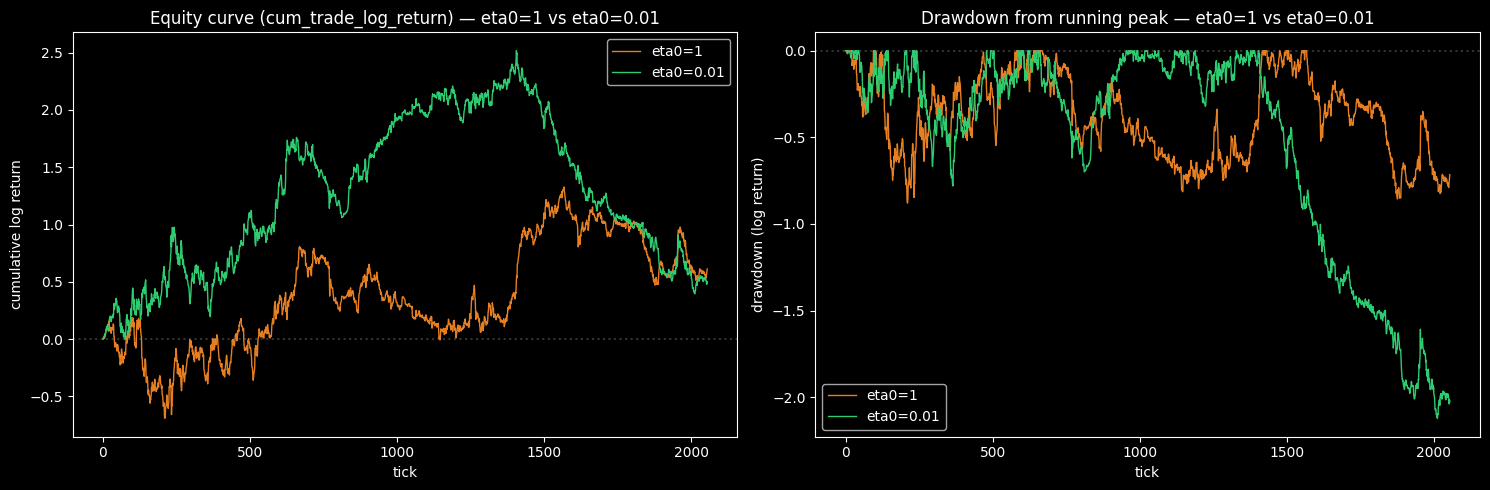

Max drawdown  eta0=1   : -0.8795860380378064
Max drawdown  eta0=0.01: -2.1222092853939394


In [14]:
def drawdown(cum_series):
    running_max = cum_series.cummax()
    return cum_series - running_max

dd_eta1 = drawdown(df_eta1['cum_trade_log_return'])
dd_eta001 = drawdown(df_eta001['cum_trade_log_return'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(df_eta1.index, df_eta1['cum_trade_log_return'], color='#e67e22', linewidth=1.0, label='eta0=1')
ax1.plot(df_eta001.index, df_eta001['cum_trade_log_return'], color='#2ecc71', linewidth=1.0, label='eta0=0.01')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.4)
ax1.set_title('Equity curve (cum_trade_log_return) — eta0=1 vs eta0=0.01')
ax1.set_xlabel('tick')
ax1.set_ylabel('cumulative log return')
ax1.legend()

ax2.plot(dd_eta1.index, dd_eta1, color='#e67e22', linewidth=1.0, label='eta0=1')
ax2.plot(dd_eta001.index, dd_eta001, color='#2ecc71', linewidth=1.0, label='eta0=0.01')
ax2.axhline(0, color='gray', linestyle=':', alpha=0.4)
ax2.set_title('Drawdown from running peak — eta0=1 vs eta0=0.01')
ax2.set_xlabel('tick')
ax2.set_ylabel('drawdown (log return)')
ax2.legend()

plt.tight_layout()
plt.show()

print('Max drawdown  eta0=1   :', dd_eta1.min())
print('Max drawdown  eta0=0.01:', dd_eta001.min())